In [17]:
import arviz as az
import numpy as np
from scipy.stats import wishart
import matplotlib.pyplot as plt
import math

# Set random seed for reproducibility (same seed of Mattia's 250D notebook)
rng = np.random.default_rng(12345)

Posterior to sample:

In [18]:
# Define the pseudo log-potential
# Gaussian log-density
D = 10
df = D

# Whishart 
# A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)

# Identity
A = np.eye(D, dtype=np.float64)

# Different std for each dimension
#sigmas = jnp.linspace(0.5, 5.0, D)  
#A = jnp.diag(1.0 / (sigmas**2))     # precision = diag(1/sigma**2)

def L(theta: jnp.ndarray, precision_mat = A) -> jnp.float32:
    assert theta.ndim == 1
    return -0.5 * jnp.vdot(theta, precision_mat @ theta) 

#automatic differentiation
logprob_and_grad = jax.value_and_grad(L)

Initialization:

In [19]:
theta0 = jnp.zeros(10)
key = jrnd.PRNGKey(0)

Warmup configuration:

In [20]:
warmup_cfg = WarmupConfig(
    num_warmup=10000,
    delta=0.8,
    adapt_mass=False,   
)

Run the algorithm:

In [21]:
# compile
NUTS_sampler_wu_jit = jax.jit(
    NUTS_sampler_wu,
    static_argnums=(1, 2, 4),  # num_warmup, num_samples, warmup_cfg
    )

In [22]:
# execute
samples, epsilon_final = NUTS_sampler_wu_jit(
    theta0=theta0,
    num_warmup=10000,
    num_samples=5000,
    key=key,
    warmup_cfg=warmup_cfg,
    j_max=10
)

Check:

In [23]:
len(samples)

5000

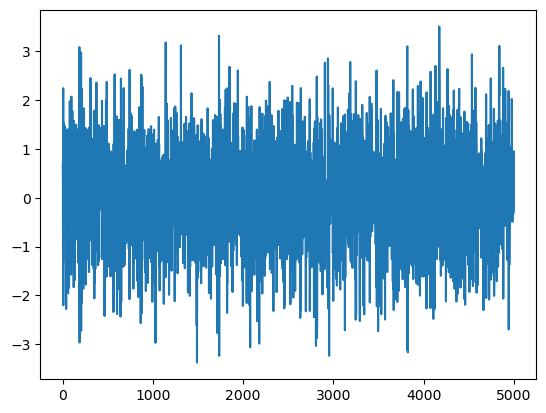

In [24]:
plt.plot(samples[:,0])

In [25]:
print("Epsilon after the warmup:", epsilon_final)

Epsilon after the warmup: 0.8954632


In [26]:
print("mean:", samples.mean(axis=0))

mean: [ 0.01737338 -0.0023331  -0.00405196 -0.03915618 -0.01417539  0.00375163
 -0.00611874  0.00105215  0.00308827  0.0337157 ]


In [27]:
print("std:", samples.std(axis=0))

std: [0.9954264  1.0001317  0.9781303  0.992387   0.99048746 0.99450696
 1.0082983  0.9764497  0.9938567  0.98576796]


In [28]:
samples.shape

(5000, 10)

/home/pira/miniconda3/envs/inf/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n7'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>,
        <Axes: xlabel='t

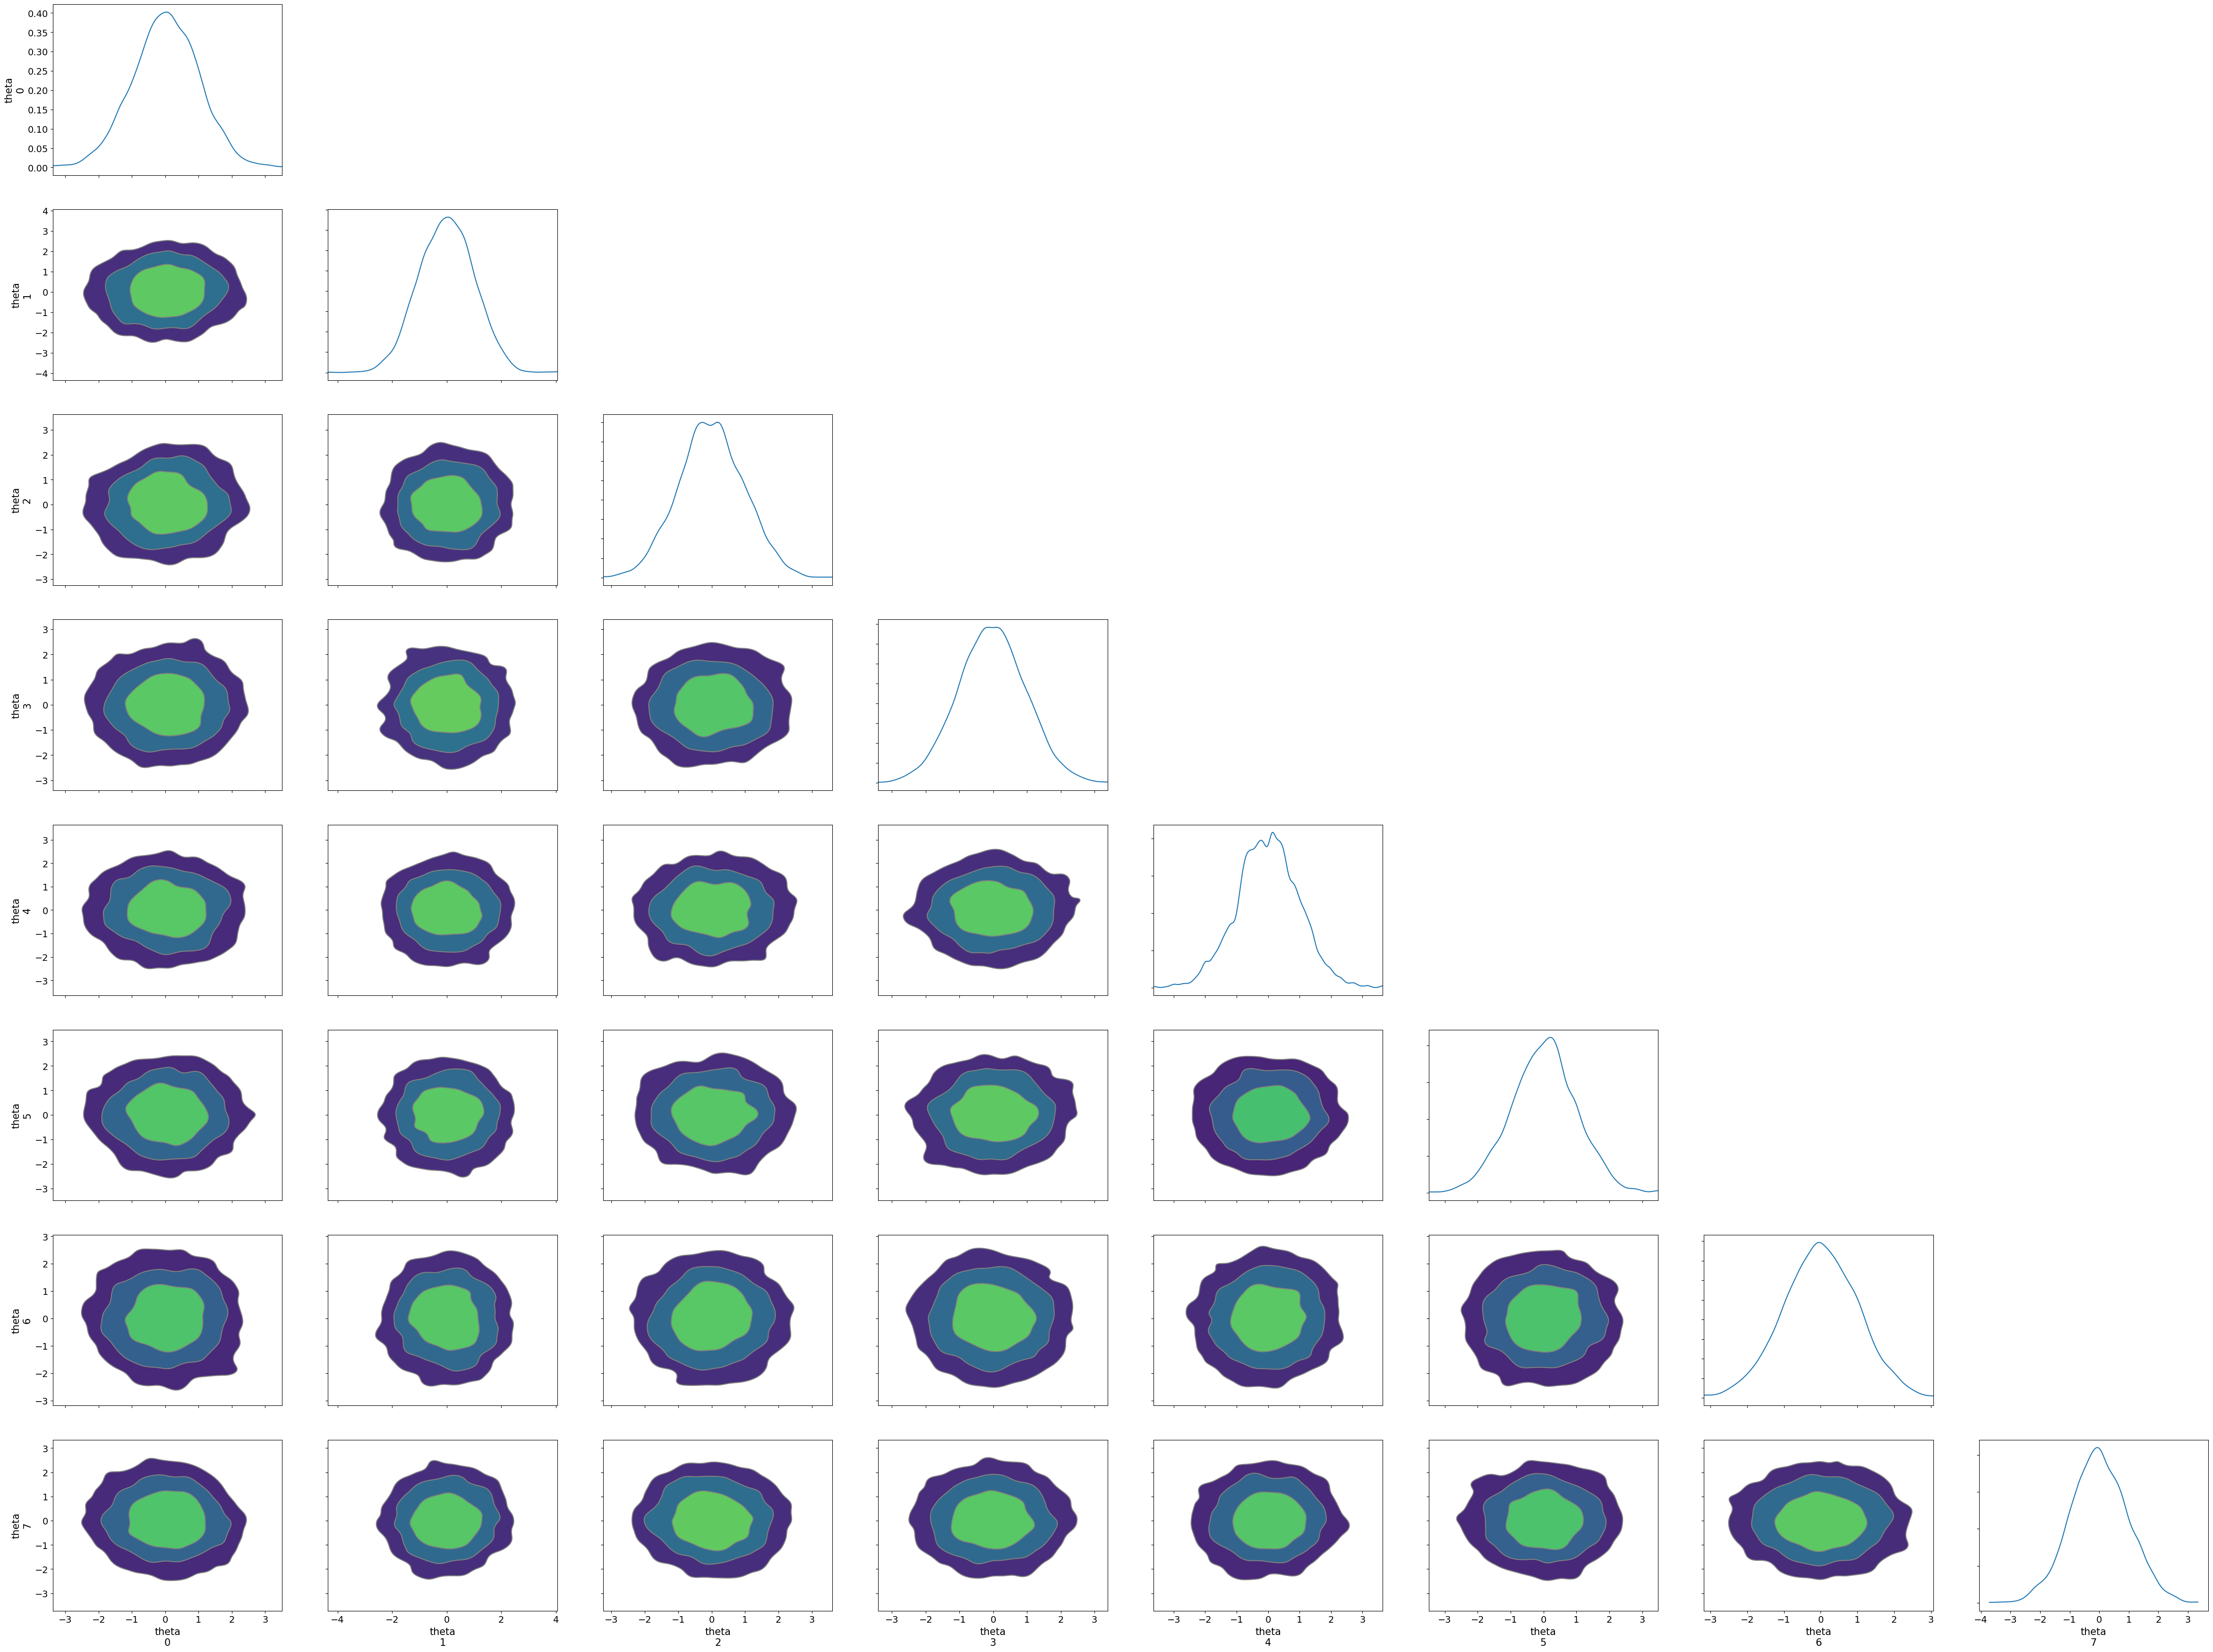

In [29]:
# add a pseudo dimension to plot the data
samples = samples[None, :, :]   # shape diventa (1, 1000, 10)

# plot the sampled data marginalized distributions
idata = az.from_dict(
    posterior={"theta": samples},
    coords={"theta_dim": np.arange(samples.shape[-1])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

In [30]:
# The theorical variance of each variable comes from inverting the precision matrix A
th_cov_mat = np.linalg.inv(A)
th_var_k = [ th_cov_mat[i,i] for i in range(D) ]
th_var_k

[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0)]

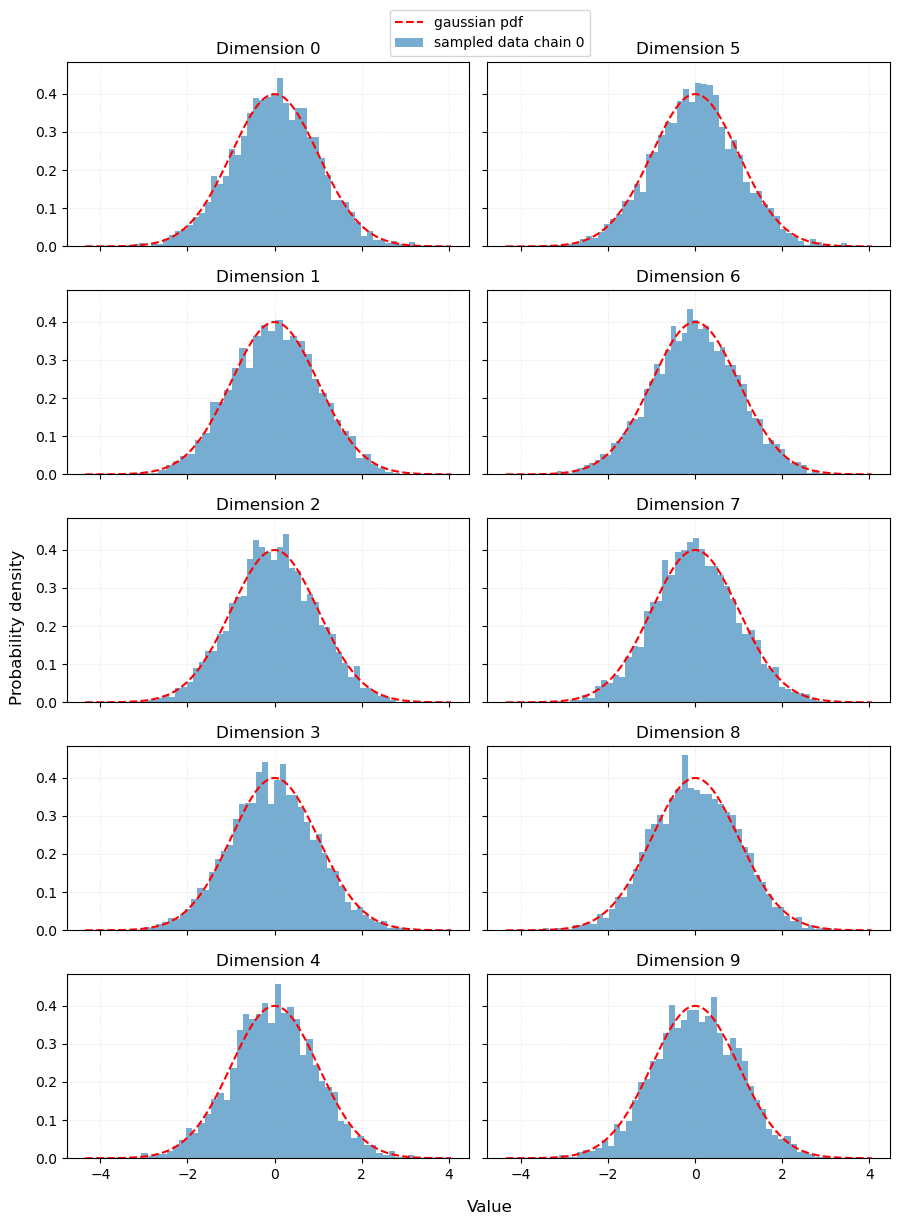

In [31]:
x = np.linspace(samples.min(), samples.max(), 1000)

fig, axs = plt.subplots(5, 2, figsize=(10, 12), sharex=True, sharey=True)

for j in range(2):        # columns
    for i in range(5):    # rows
        
        k = i + 5*j       # global index of the variable (0..9)

        var = th_var_k[k]
        norm_factor = 1 / np.sqrt(2 * np.pi * var)
        pdf = norm_factor * np.exp(-(x**2) / (2 * var))

        axs[i, j].plot(x, pdf, color='red', label='gaussian pdf', linestyle= '--')
        axs[i, j].hist(samples[0,:, k] , bins=50, density=True, alpha=0.6, label='sampled data chain 0')
        #axs[i, j].hist(samples_flat[2000:4000, k] , bins=50, density=True, alpha=0.6, label='sampled data chain 1')

        # add a grid
        axs[i, j].grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

        axs[i, j].set_title(f"Dimension {k}")

# --- LEGENDA UNICA ---
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02))

# --- ETICHETTE GLOBALI ---
fig.supxlabel("Value")
fig.supylabel("Probability density")

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.savefig("data_dist.png", dpi=300, bbox_inches="tight")
plt.show()

## Kolmogorov-Smirnov test
https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

The Kolmogorov-Smirnov test is suitable only for 1D distributions, so let's use it to evaluate the distributions of the sampled data along the single directions. In this way we can evaluate how much every single variable empirical distribution is far/near the theoretical one. Here I performed only the KS-test to verify if the distribution of a single chain comes from the theoretical gaussian distribuiton adopted to generate them via NUTS. We can also use the KS-test to check if two chains come from the same distribution...
Start looking at the single variable data sampled with NUTS:

In [32]:
from scipy.stats import kstest, norm

# y = 1D samples (j-th component)
stats = []
pvals = []

for j in range(D-1):
    comp = np.asarray(samples[0][:, j])   # explicit conversion
    stat, pval = kstest(comp, 'norm', args=(0, 1))
    stats.append(float(stat))
    pvals.append(float(pval))
    

print("KS statistic: \n", stats, "\n")
print("p-value: \n", pvals, "\n")




KS statistic: 
 [0.01661705500434779, 0.013546231820621202, 0.014350027111342256, 0.02361945200809118, 0.01669495109492536, 0.01455111066543413, 0.008917126375355022, 0.015901427449485778, 0.012757017533638337] 

p-value: 
 [0.12499427882955183, 0.3151069254593174, 0.252164958570241, 0.00743296466867703, 0.12178820814590363, 0.2379724278792099, 0.8180012632827658, 0.157783865261363, 0.3866755344706304] 



In the test we have:

$$
H_0 : \text{the sample follows the theoretical distribution} \ F(x) 
$$
$$
H_1 : \text{the sample comes from another distribution} 
$$

The $p-value$ tells us how confident we are in accepting $H_0$. 


In [33]:
stats = []
pvals = []

for j in range(D):
    comp = np.asarray(samples[0, :, j])   # JAX -> NumPy
    std = np.sqrt(th_cov_mat[j, j])         # deviazione standard teorica
    stat, pval = kstest(comp, 'norm', args=(0, std))
    stats.append(stat)
    pvals.append(pval)


print("KS statistic: \n", stats, "\n")
print("p-value: \n", pvals, "\n")

KS statistic: 
 [np.float64(0.01661705500434779), np.float64(0.013546231820621202), np.float64(0.014350027111342256), np.float64(0.02361945200809118), np.float64(0.01669495109492536), np.float64(0.01455111066543413), np.float64(0.008917126375355022), np.float64(0.015901427449485778), np.float64(0.012757017533638337), np.float64(0.02252722558889686)] 

p-value: 
 [np.float64(0.12499427882955183), np.float64(0.3151069254593174), np.float64(0.252164958570241), np.float64(0.00743296466867703), np.float64(0.12178820814590363), np.float64(0.2379724278792099), np.float64(0.8180012632827658), np.float64(0.157783865261363), np.float64(0.3866755344706304), np.float64(0.012314488144329942)] 



In [34]:
print(th_cov_mat)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [35]:
emp_cov = np.cov(samples[0], rowvar=False)
print(emp_cov)

[[ 9.91071966e-01  4.39463271e-02  3.35140294e-02  2.39365193e-02
  -6.94171592e-03 -1.06599798e-03 -8.00854551e-03 -5.21438484e-02
  -3.25229933e-02  3.42307759e-02]
 [ 4.39463271e-02  1.00046361e+00  1.30119728e-02  1.46571265e-03
   1.36120948e-02  5.23660962e-03 -2.68358421e-02  2.44828323e-02
  -9.65760836e-03  4.16933271e-02]
 [ 3.35140294e-02  1.30119728e-02  9.56930229e-01  7.69977847e-03
   6.75452995e-03 -7.55557105e-03  4.11974968e-02 -3.89341076e-02
  -7.24749807e-03  4.24360982e-02]
 [ 2.39365193e-02  1.46571265e-03  7.69977847e-03  9.85028963e-01
   4.02774863e-03  4.53371768e-02 -6.70176695e-03  1.49645841e-02
  -3.73596881e-04  2.93001100e-02]
 [-6.94171592e-03  1.36120948e-02  6.75452995e-03  4.02774863e-03
   9.81261726e-01  2.91908507e-02  1.69439107e-02  1.48802721e-02
  -4.41898126e-03 -3.71947290e-02]
 [-1.06599798e-03  5.23660962e-03 -7.55557105e-03  4.53371768e-02
   2.91908507e-02  9.89241969e-01  3.33012971e-02 -1.91679530e-02
  -1.86928359e-02 -3.34354335e-03

In [36]:
rel_err = np.abs(emp_cov - th_cov_mat) / np.abs(th_cov_mat)
print(rel_err)

[[0.00892803        inf        inf        inf        inf        inf
         inf        inf        inf        inf]
 [       inf 0.00046361        inf        inf        inf        inf
         inf        inf        inf        inf]
 [       inf        inf 0.04306977        inf        inf        inf
         inf        inf        inf        inf]
 [       inf        inf        inf 0.01497104        inf        inf
         inf        inf        inf        inf]
 [       inf        inf        inf        inf 0.01873827        inf
         inf        inf        inf        inf]
 [       inf        inf        inf        inf        inf 0.01075803
         inf        inf        inf        inf]
 [       inf        inf        inf        inf        inf        inf
  0.01686865        inf        inf        inf]
 [       inf        inf        inf        inf        inf        inf
         inf 0.04635513        inf        inf]
 [       inf        inf        inf        inf        inf        inf
         inf

/tmp/ipykernel_16222/4181805260.py:1: RuntimeWarning: divide by zero encountered in divide
  rel_err = np.abs(emp_cov - th_cov_mat) / np.abs(th_cov_mat)


In [39]:
def qq_plot_marginals(samples, Sigma):
    """
    samples: array (N, D)
    Sigma: theorical covariance matrix (D, D) = A^{-1}
    """
    samples = np.asarray(samples)
    Sigma = np.asarray(Sigma)

    N, D = samples.shape
    rows, cols = 5, 2  # D=10

    fig, axes = plt.subplots(rows, cols, figsize=(12, 20))
    axes = axes.flatten()

    for j in range(D):
        ax = axes[j]

        # variables of the j-th dimension
        x = np.sort(samples[:, j])

        # theorical quantiles of the gaussian with diag(cov_matrix)=Sigma[j,j]
        std = np.sqrt(Sigma[j, j])
        q = norm.ppf(np.linspace(0.001, 0.999, N), loc=0.0, scale=std)

        # QQ plot
        ax.plot(q, x, 'o', markersize=2)
        ax.plot(q, q, 'r--', linewidth=1)

        ax.set_title(f"Dim {j} — Theoretical std={std:.3f}")
        ax.set_xlabel("Theoretical Quantiles")
        ax.set_ylabel("Empirical Quantiles")
        ax.grid(True)

    # remove empty plots if D < rows*cols
    for k in range(D, rows*cols):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.savefig("KS_test.png", dpi=300, bbox_inches="tight")
    plt.show()



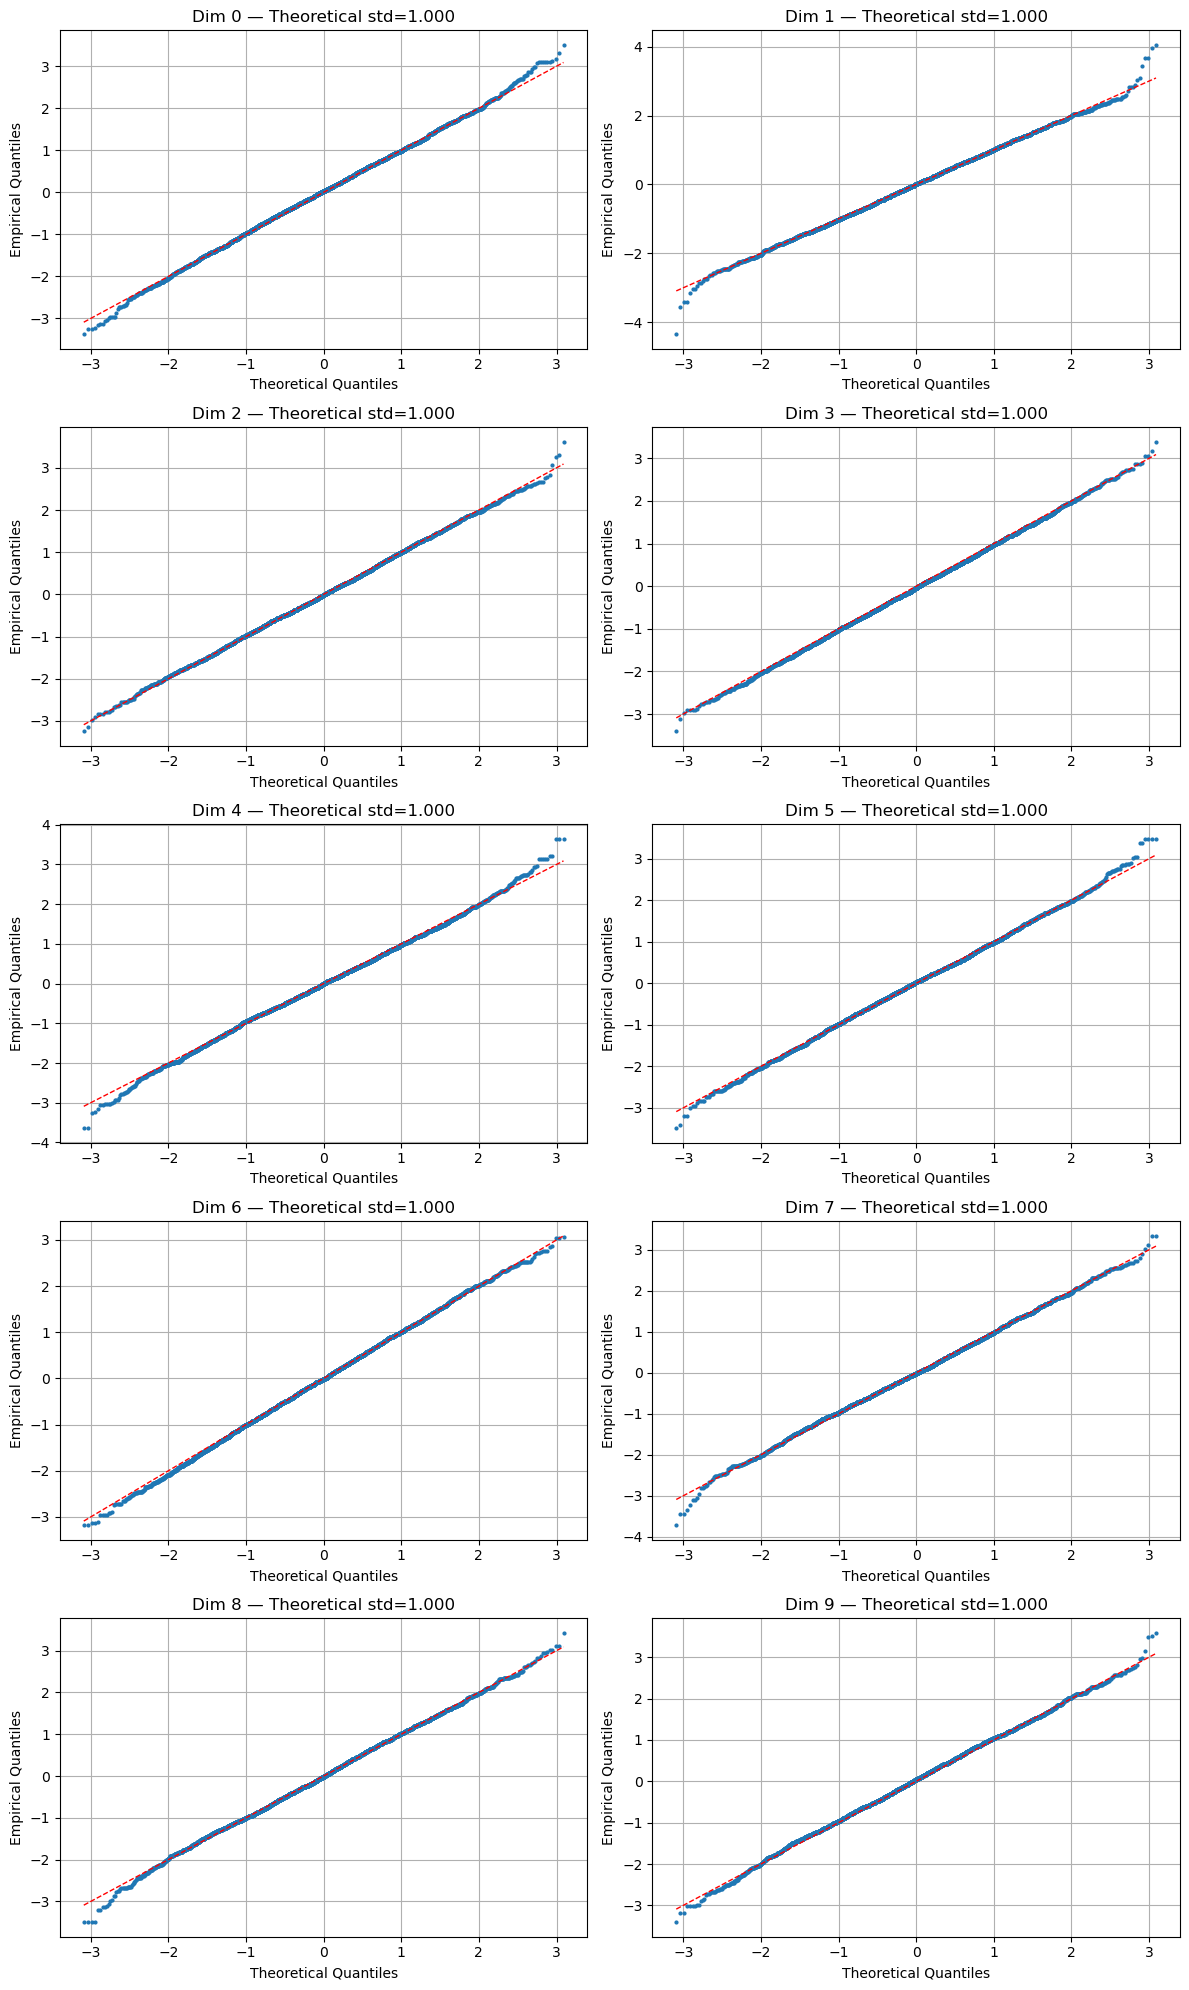

In [40]:
qq_plot_marginals(samples[0], th_cov_mat)